# Лабораторная работа №5

### Выполнила Дворкина Ева, группа НКАбд-01-22

импорт библиотек:

In [41]:
import numpy as np
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from math import sin, cos, sqrt, asin, pi
import matplotlib.patches as mpatches
from itertools import product
from collections import namedtuple
import ipywidgets as widgets


plt.style.use('black_white.mplstyle') #набор предопределенных стилей, 
#которые можно применить к графикам, чтобы быстро изменить их внешний вид.
#Например, в этом файле у меня установлена mathtext.fontset : cm, чтобы у буквы X (например) был вид типа $mathnormal{x}$, 
#ну красивая буква как в латехе!

In [42]:
Polyhedron = namedtuple(typename='Polyhedron', field_names=('vertices', 'faces'))

- Проекторы — прямые, проходящие через каждую точку
объекта и пересекающиеся в произвольной точке —
центре проекции.
- Проекторы пересекаются с некоторой плоскостью,
которая называется плоскостью проекции.
- Если центр проекции находится в бесконечно
удаленной точке, то проекторы становятся
параллельными прямыми и в результате получается
параллельная проекция.

**Перспективная проекция — проекторы не параллельны и исходят из одной точки.**

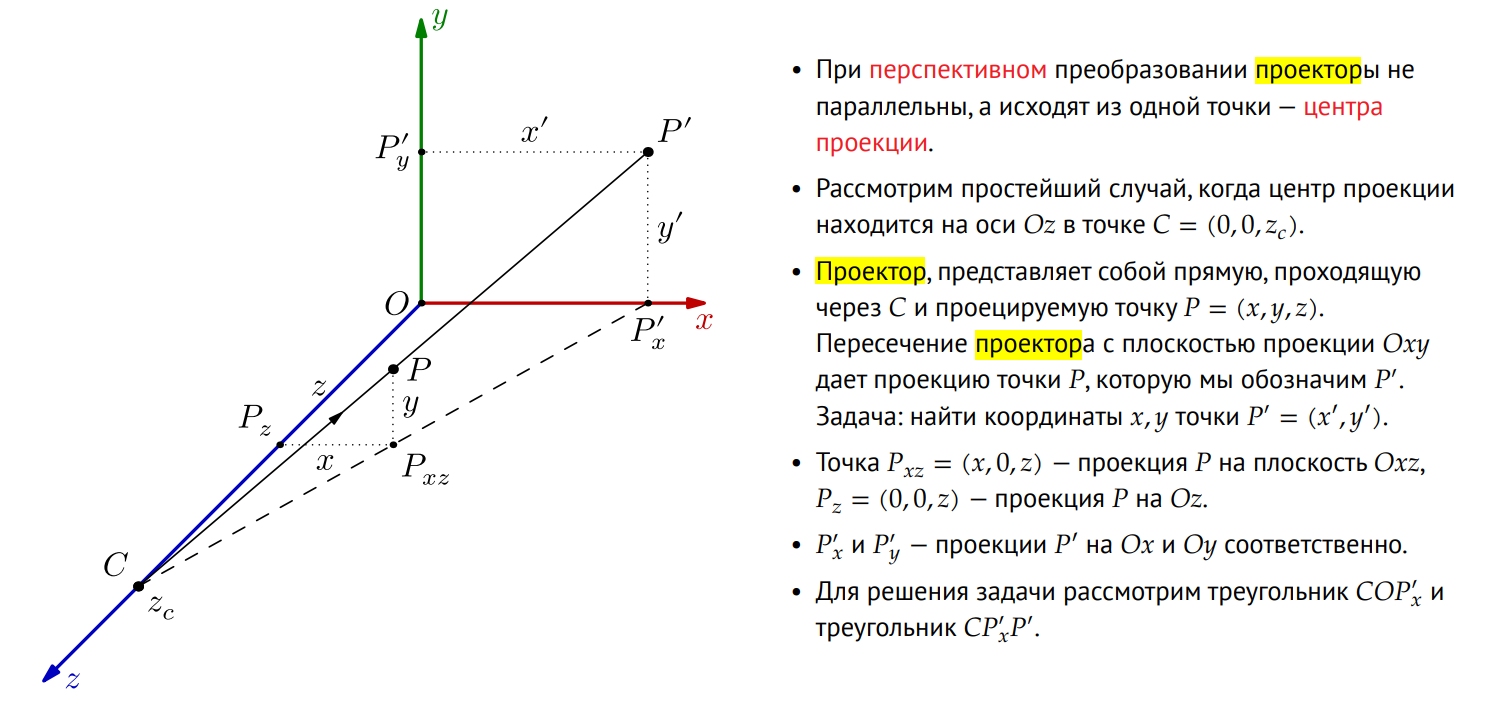


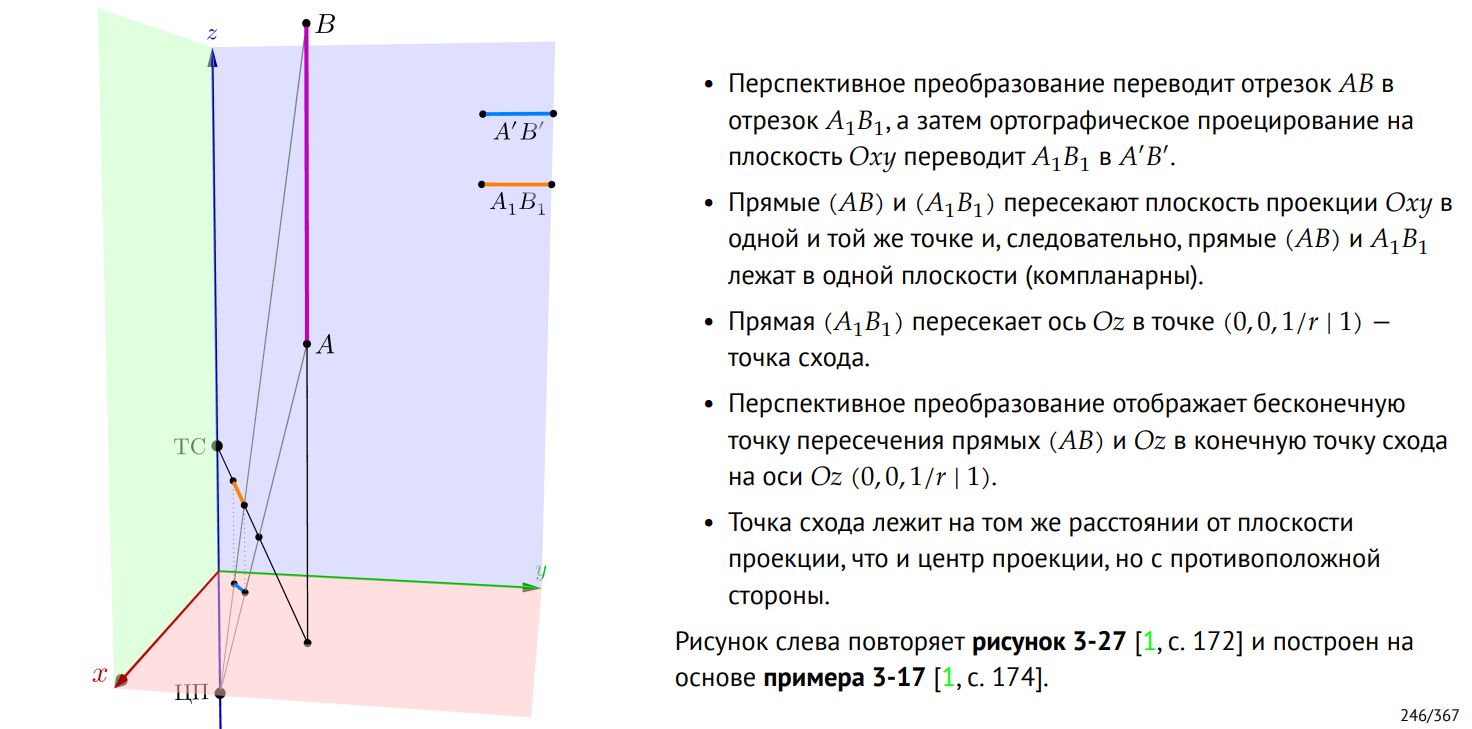

## Цель лабораторной работы

Научится вычислять и визуализировать перспективные проекции.

## Задания

Во всех заданиях можно использовать только двухмерные средства рисования. Невидимые ребра можно не рисовать вовсе, рисовать пунктирной или серой линией.

## Задание 1

- Написать программу, которая рисует единичный куб позволяет вращать его вокруг локальных осей $Ox$ и $Oy$, перемещать (транслировать) в любом направлении, а затем проецировать одноточечной или двуточечной перспективной проекцией на плоскость $Oxy$.
- Создать, на выбор, или анимацию, в которой куб будет перемещаться и вращаться отображаясь при этом в перспективной проекции, или использовать несколько ползунков, которыми можно будет задавать углы поворотов и смещение по осям для задания трансляции. Изображение с кубом при этом должно перерисовываться.

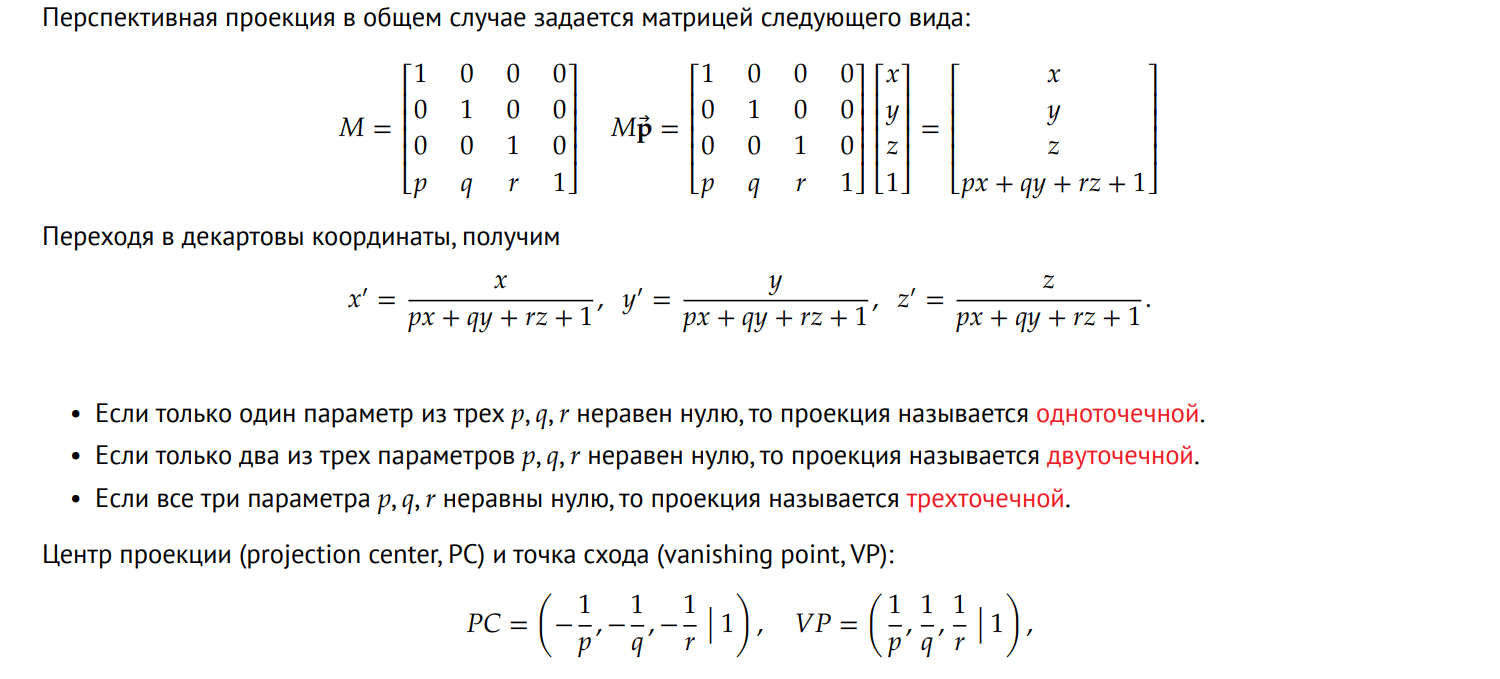

In [176]:
def rotation_ox(a):
    return np.array([
        [1,0,0,0],
        [0, cos(a), -sin(a), 0],
        [0, sin(a), cos(a), 0],
        [0, 0, 0, 1]
    ])
    
def rotation_oy(a):
    return np.array([
        [cos(a), 0, sin(a), 0],
        [0, 1, 0, 0],
        [-sin(a), 0, cos(a), 0],
        [0, 0, 0, 1]
    ])
    
def rotation_oz(a):
    return np.array([
        [cos(a), -sin(a), 0, 0],
        [sin(a), cos(a), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

def translate(tx, ty, tz):
    return np.array([
        [1, 0, 0, tx],
        [0, 1, 0, ty],
        [0, 0, 1, tz],
        [0, 0, 0, 1]
    ])

def perspective(p, q, r):
    return np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 0],
        [p, q, r, 1]
    ])

def normalize_in_place(points):
    last_column = points[:, -1]
    points[:, :] = points / last_column[:, np.newaxis]

def normalize(points):
    return points / points[:, -1][:, np.newaxis]

In [177]:
def S_abc(vertices, face): #ура ориентированная площадь
    p1, p2, p3 = vertices[face][0:3, (0, 1, 3)] #(х - 0, у - 1, v - 3)
    #0:3 - первые три точки индексы 0, 1, 2
    return np.linalg.det(np.column_stack((p1, p2, p3))) #np.column_stack - собирает массивы в колонку, получаем матричку, по формуле выше считаем
#определитель

In [178]:
XYZ_vectors = np.array([[1, 0, 0, 0],
                       [0, 1, 0, 0],
                       [0, 0, 1, 0],
                       [0, 0, 0, 1]])

In [179]:
cub = Polyhedron(vertices=np.array([[0,0,0,1],
                                    [0,1,0,1],
                                    [1,1,0,1],
                                    [1,0,0,1],
                                    [0,0,1,1],
                                    [0,1,1,1],
                                    [1,1,1,1],
                                    [1,0,1,1]]), faces = [[0,4,5,1],
                                                  [0,3,7,4],
                                                  [3,2,6,7],
                                                  [2,1,5,6],
                                                  [0,1,2,3],
                                                  [6,5,4,7]])

In [180]:
new_vertices = cub.vertices @ perspective(0, 0, -0.1).T 
last_column = new_vertices[:, -1]

new_vertices / last_column[:, np.newaxis]

array([[0.        , 0.        , 0.        , 1.        ],
       [0.        , 1.        , 0.        , 1.        ],
       [1.        , 1.        , 0.        , 1.        ],
       [1.        , 0.        , 0.        , 1.        ],
       [0.        , 0.        , 0.        , 1.        ],
       [0.        , 1.11111111, 0.        , 1.        ],
       [1.11111111, 1.11111111, 0.        , 1.        ],
       [1.11111111, 0.        , 0.        , 1.        ]])

In [181]:
normalize_in_place(cub.vertices)

In [182]:
normalize(new_vertices)

array([[0.        , 0.        , 0.        , 1.        ],
       [0.        , 1.        , 0.        , 1.        ],
       [1.        , 1.        , 0.        , 1.        ],
       [1.        , 0.        , 0.        , 1.        ],
       [0.        , 0.        , 0.        , 1.        ],
       [0.        , 1.11111111, 0.        , 1.        ],
       [1.11111111, 1.11111111, 0.        , 1.        ],
       [1.11111111, 0.        , 0.        , 1.        ]])

In [183]:
def draw_cub(p, q, r, tx=0, ty=0, tz=0, a=0, b=0):
    fig01 = plt.figure(num=1, figsize=(5,5))
    ax01 = fig01.add_subplot(1, 1, 1)
    ax01.set_aspect('equal')
    ax01.set_xlim(-5, 5)
    ax01.set_ylim(-5,5)

    ax01.axhline(0)  # Горизонтальная линия Ox
    ax01.axvline(0) 
    
    t_vert = cub.vertices @ translate(-0.5, -0.5, 0).T
    t_vert = t_vert @ rotation_oy(np.deg2rad(a)) @ rotation_ox(np.deg2rad(b))
    t_vert = t_vert @ translate(tx, ty, tz).T @ perspective(p, q, r).T 
    t_vert = normalize(t_vert)
    
    for face in cub.faces:
        polygon = mpatches.Polygon(
            xy = t_vert[face][:, 0:2],
            closed=True, fill=False, facecolor = 'grey',
            edgecolor='k' if S_abc(t_vert, face) > 0 else 'lightgrey',
            zorder = 10 if S_abc(t_vert, face) > 0 else - 10
        )
        ax01.add_patch(polygon)

In [184]:
widgets.interact(
    draw_cub,
    p=(-0.5, 0.5, 0.01),
    q=(-0.5, 0.5, 0.01),
    r=(-0.5, 0.5, 0.01),
    tx=(-5, 5, 0.5),
    ty=(-5, 5, 0.5),
    tz=(-5, 5, 0.5),
    a=(-90, 90, 1),
    b=(-90, 90, 1)
)

interactive(children=(FloatSlider(value=0.0, description='p', max=0.5, min=-0.5, step=0.01), FloatSlider(value…

<function __main__.draw_cub(p, q, r, tx=0, ty=0, tz=0, a=0, b=0)>

У МЕНЯ СНАЧАЛА НЕ ЗАРАБОТАЛА ПЕРСПЕКТИВА И Я УСПУГАЛАСЬ А ПОТОМ ПОНЯЛА ЧТО Я НОРМАЛИЗАЦИЮ НЕ СДЕЛАЛА И ВЫДОХНУЛА!!

В задании: 
**Перспективная проекция куба c коэффициентом проективной матрицы 𝑟 = −0.25. Исходно
куб находился в центре координат, но затем его сместили вверх и вниз по оси 𝑂𝑦 и повернули
вокруг одной из граней на 60 и 120.**
там где кубик наверху - вокруг ОУ на 120 (-60), а по у подняли на 2 (из презы)
там где кубик внизу вокруг ОУ на 60 а по у  опустили на -0.2

Кстати на картинке повернут не центрированный куб. Пришлось до этого додумываться(

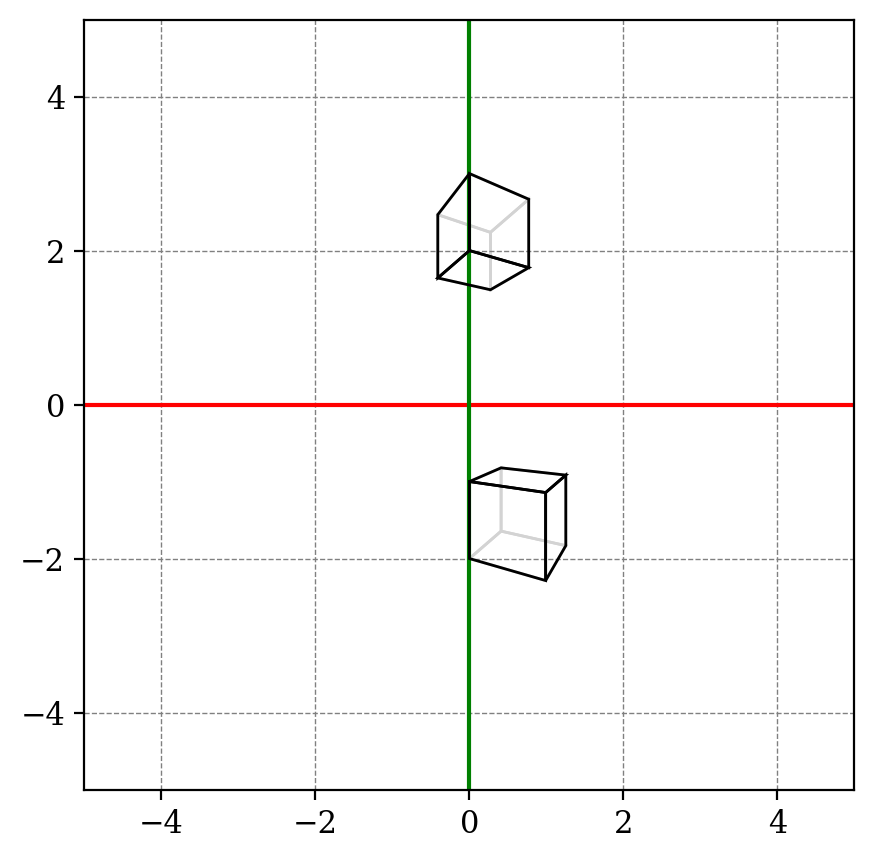

In [116]:
fig01 = plt.figure(num=1, figsize=(5,5))
ax01 = fig01.add_subplot(1, 1, 1)
ax01.set_aspect('equal')
ax01.set_xlim(-5, 5)
ax01.set_ylim(-5,5)

ax01.axhline(0, color='r')  # Горизонтальная линия Ox
ax01.axvline(0, color='g') 

t_vert = cub.vertices #@ translate(-0.5, -0.5, 0).T
t_vert = t_vert @ rotation_oy(np.deg2rad(-120)) #@ rotation_ox(np.deg2rad(0))
t_vert = t_vert @ translate(0, 2, 0).T @ perspective(0, 0, -0.25).T 
t_vert = normalize(t_vert)

for face in cub.faces:
    polygon = mpatches.Polygon(
        xy = t_vert[face][:, 0:2],
        closed=True, fill=False, facecolor = 'grey',
        edgecolor='k' if S_abc(t_vert, face) > 0 else 'lightgrey',
        zorder = 10 if S_abc(t_vert, face) > 0 else - 10
    )
    ax01.add_patch(polygon)


t_vert = cub.vertices #@ translate(-0.5, -0.5, 0).T
t_vert = t_vert @ rotation_oy(np.deg2rad(-60)) @ rotation_ox(np.deg2rad(0))
t_vert = t_vert @ translate(0, -2, 0).T @ perspective(0, 0, -0.25).T 
t_vert = normalize(t_vert)

for face in cub.faces:
    polygon1 = mpatches.Polygon(
        xy = t_vert[face][:, 0:2],
        closed=True, fill=False, facecolor = 'grey',
        edgecolor='k' if S_abc(t_vert, face) > 0 else 'lightgrey',
        zorder = 10 if S_abc(t_vert, face) > 0 else - 10
    )
    ax01.add_patch(polygon1)

## Задание 2

К предыдущей программе добавьте вычисление точек схода. Изобразите (нарисуйте) прямые, содержащие ребра куба и покажите, что они пересекаются в точках схода.

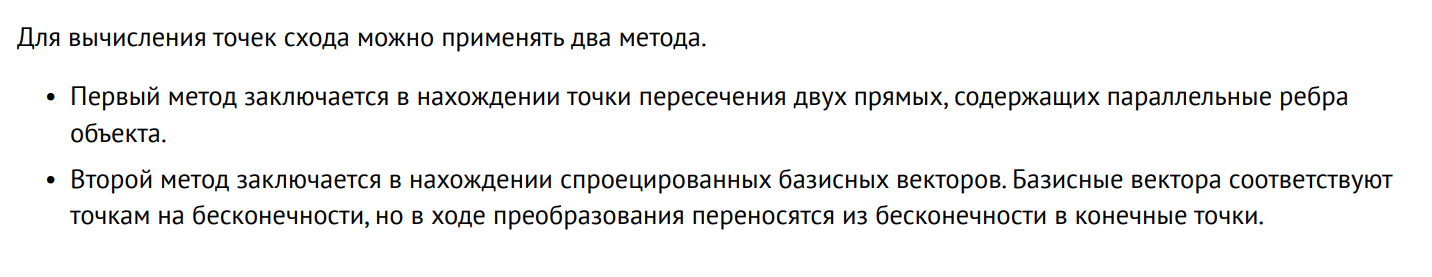

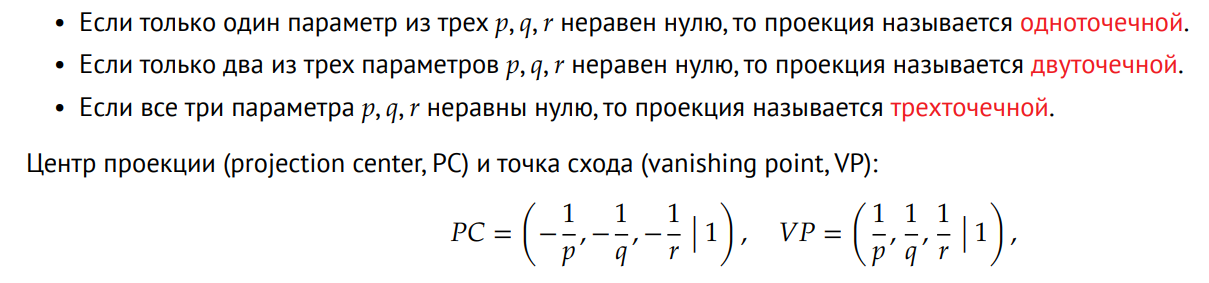

Пока я искала как найти точки схода не по прямым, узнала что можно в обратную сторону из перспективы в обычные координаты
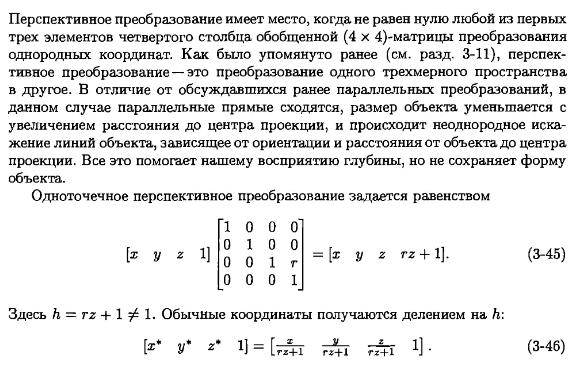

In [276]:
def draw_cub_lines(p, q, r, tx=0, ty=0, tz=0, a=0, b=0):
    fig01 = plt.figure(num=1, figsize=(5,5))
    ax01 = fig01.add_subplot(1, 1, 1)
    ax01.set_aspect('equal')
    ax01.set_xlim(-5, 5)
    ax01.set_ylim(-5,5)

    ax01.axhline(0, color='r')  # Горизонтальная линия Ox
    ax01.axvline(0, color='g') 


    
    t_vert = cub.vertices @ translate(-0.5, -0.5, 0).T
    t_vert = t_vert @ rotation_oy(np.deg2rad(a)) @ rotation_ox(np.deg2rad(b))
    t_vert = t_vert @ translate(tx, ty, tz).T @ perspective(p, q, r).T 
    t_vert = normalize(t_vert)

    a = normalize(n @ rotation_oy(np.deg2rad(a)) @ rotation_ox(np.deg2rad(b)) @ translate(tx, ty, tz).T @ perspective(p, q, r).T)
    ax01.plot(a[0][0], a[0][1], marker='o', markersize=2, zorder=10)
    ax01.plot(a[1][0], a[1][1], marker='o', markersize=2, zorder=10)
    ax01.plot(a[2][0], a[2][1], marker='o', markersize=2, zorder=10)

    
#цикл только для куба((
    for (i,j) in [(0, 4), (3, 7), (1, 5), (2, 6), (0,3), (4, 7), (1, 2), (5, 6)]:
        ax01.axline(xy1=t_vert[i][0:2], xy2=t_vert[j][0:2],
                   ls='--',
                   color='pink',
                   lw=0.5,
                   zorder=-10) #зордер это порядок! чтобы линии не перекрывали основной рисунок

    for face in cub.faces:
        polygon = mpatches.Polygon(
            xy = t_vert[face][:, 0:2],
            closed=True, fill=False, facecolor = 'grey',
            edgecolor='k' if S_abc(t_vert, face) > 0 else 'lightgrey',
            zorder = 10 if S_abc(t_vert, face) > 0 else - 10
        )
        ax01.add_patch(polygon)

In [277]:
widgets.interact(
    draw_cub_lines,
    p=(-0.5, 0.5, 0.01),
    q=(-0.5, 0.5, 0.01),
    r=(-0.5, 0.5, 0.01),
    tx=(-5, 5, 0.5),
    ty=(-5, 5, 0.5),
    tz=(-5, 5, 0.5),
    a=(-180, 180, 1),
    b=(-180, 180, 1)
)

#ошибка сразу выдается потому что точки 0 и 4 оказываются одинаковымы (в одной пл-ти по z) если мы кубик не поворачиваем

interactive(children=(FloatSlider(value=0.0, description='p', max=0.5, min=-0.5, step=0.01), FloatSlider(value…

<function __main__.draw_cub_lines(p, q, r, tx=0, ty=0, tz=0, a=0, b=0)>

В задании: 
**Перспективная проекция куба c коэффициентом проективной матрицы 𝑟 = −0.25. Исходно
куб находился в центре координат, но затем его сместили вверх и вниз по оси 𝑂𝑦 и повернули
вокруг одной из граней на 60 и 120.**
там где кубик наверху - вокруг ОУ на 120 (выставила -120 в картинке), а по у подняли на 2 (из презы)
там где кубик внизу вокруг ОУ на 60 а по у  опустили на -0.2, и там точки схода разные, должна быть -0.1, а не -0.25

Кстати на картинке повернут не центрированный куб. Пришлось до этого додумываться(

МАТРИЦА ПРЕОБРАЗОВАНИЙ ДЛЯ БАЗИСНЫХ ВЕКТОРОВ

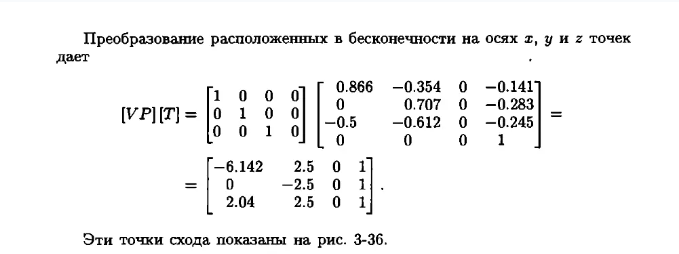

главное не забыть нормализацию! а то я сначала забыла и думаю почему все идет по одному месту^^

In [253]:
##матрица преобразования

preobr = rotation_oy(np.deg2rad(-120)) @ rotation_ox(np.deg2rad(0)) @ translate(0, 2, 0).T @ perspective(0, 0, -0.25).T

In [254]:
n = np.array([[1, 0, 0, 0],
                       [0, 1, 0, 0],
                       [0, 0, 1, 0]])

In [256]:
a = normalize(n @ preobr)

C:\Users\Yuri Kamori\AppData\Local\Temp\ipykernel_280\1639250463.py:46: RuntimeWarning: divide by zero encountered in divide
  return points / points[:, -1][:, np.newaxis]
C:\Users\Yuri Kamori\AppData\Local\Temp\ipykernel_280\1639250463.py:46: RuntimeWarning: invalid value encountered in divide
  return points / points[:, -1][:, np.newaxis]


In [ ]:

a  = n @ rotation_oy(np.deg2rad(-120)) @ rotation_ox(np.deg2rad(0)) @ translate(0, 2, 0).T @ perspective(0, 0, -0.25).T

C:\Users\Yuri Kamori\AppData\Local\Temp\ipykernel_280\1639250463.py:46: RuntimeWarning: divide by zero encountered in divide
  return points / points[:, -1][:, np.newaxis]
C:\Users\Yuri Kamori\AppData\Local\Temp\ipykernel_280\1639250463.py:46: RuntimeWarning: invalid value encountered in divide
  return points / points[:, -1][:, np.newaxis]


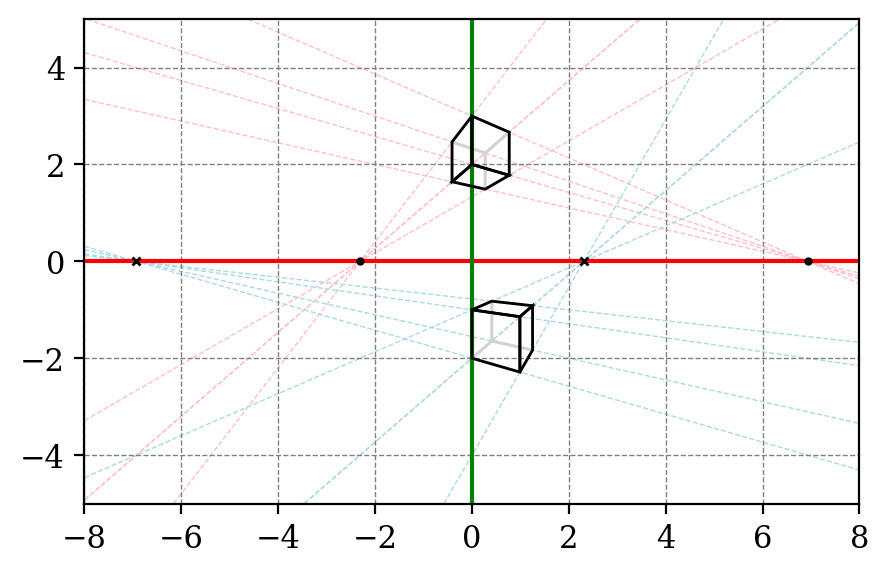

In [280]:

fig01 = plt.figure(num=1, figsize=(5,5))
ax01 = fig01.add_subplot(1, 1, 1)
ax01.set_aspect('equal')
ax01.set_xlim(-8, 8)
ax01.set_ylim(-5,5)

ax01.axhline(0, color='r')  # Горизонтальная линия Ox
ax01.axvline(0, color='g') 



t_vert = cub.vertices #@ translate(-0.5, -0.5, 0).T
t_vert = t_vert @ rotation_oy(np.deg2rad(-120)) @ rotation_ox(np.deg2rad(0))
t_vert = t_vert @ translate(0, 2, 0).T @ perspective(0, 0, -0.25).T 
t_vert = normalize(t_vert)

#цикл только для куба((
for (i,j) in [(0, 4), (3, 7), (1, 5), (2, 6), (0,3), (4, 7), (1, 2), (5, 6)]:
    ax01.axline(xy1=t_vert[i][0:2], xy2=t_vert[j][0:2],
               ls='--',
               color='pink',
               lw=0.5,
               zorder=-10) #зордер это порядок! чтобы линии не перекрывали основной рисунок


for face in cub.faces:
    polygon = mpatches.Polygon(
        xy = t_vert[face][:, 0:2],
        closed=True, fill=False, facecolor = 'grey',
        edgecolor='k' if S_abc(t_vert, face) > 0 else 'lightgrey',
        zorder = 10 if S_abc(t_vert, face) > 0 else - 10
    )
    ax01.add_patch(polygon)
    
a  = normalize(n @ rotation_oy(np.deg2rad(-120)) @ rotation_ox(np.deg2rad(0)) @ translate(0, 2, 0).T @ perspective(0, 0, -0.25).T)

ax01.plot(a[0][0], a[0][1], marker='o', markersize=2, zorder=10)
ax01.plot(a[1][0], a[1][1], marker='o', markersize=2, zorder=10)
ax01.plot(a[2][0], a[2][1], marker='o', markersize=2, zorder=10)

#нижний строим
t_vert = cub.vertices #@ translate(-0.5, -0.5, 0).T
t_vert = t_vert @ rotation_oy(np.deg2rad(-60)) @ rotation_ox(np.deg2rad(0))
t_vert = t_vert @ translate(0, -2, 0).T @ perspective(0, 0, -0.25).T 
t_vert = normalize(t_vert)

#цикл только для куба((
for (i,j) in [(0, 4), (3, 7), (1, 5), (2, 6), (0,3), (4, 7), (1, 2), (5, 6)]:
    ax01.axline(xy1=t_vert[i][0:2], xy2=t_vert[j][0:2],
               ls='--',
               color='lightblue',
               lw=0.5,
               zorder=-10) #зордер это порядок! чтобы линии не перекрывали основной рисунок
    

for face in cub.faces:
    polygon1 = mpatches.Polygon(
        xy = t_vert[face][:, 0:2],
        closed=True, fill=False, facecolor = 'grey',
        edgecolor='k' if S_abc(t_vert, face) > 0 else 'lightgrey',
        zorder = 10 if S_abc(t_vert, face) > 0 else - 10
    )
    ax01.add_patch(polygon1)

a  = normalize(n @ rotation_oy(np.deg2rad(-60)) @ rotation_ox(np.deg2rad(0)) @ translate(0, -2, 0).T @ perspective(0, 0, -0.25).T)

ax01.plot(a[0][0], a[0][1], marker='x', markersize=3, zorder=10)
ax01.plot(a[1][0], a[1][1], marker='x', markersize=3, zorder=10)
ax01.plot(a[2][0], a[2][1], marker='x', markersize=3, zorder=10)

## Задание 3 

Изобразите (нарисуйте) параболу в перспективной проекции. Для создания рисунка использовалась перспективное преобразование с параметрами:
$$
𝑝 = 0
$$
$$
𝑞 = 0.2
$$
$$
𝑟 = −0.1 
$$
Выполнение лабораторной пойдет **веселее**, если организовать ползунок, который будет регулировать значение параметра 𝑞. Значение параметра 𝑟 также можно регулировать, но он влияет на конечный рисунок не так значительно.

In [314]:
# координаты параболы
x = np.linspace(-10, 10, 1000)
y = x**2  


In [319]:
parab = np.array([x, y, np.zeros(1000), np.ones(1000)]).T

In [321]:
parab[:, 0:2]

array([[-10.        , 100.        ],
       [ -9.97997998,  99.6000004 ],
       [ -9.95995996,  99.2008024 ],
       ...,
       [  9.95995996,  99.2008024 ],
       [  9.97997998,  99.6000004 ],
       [ 10.        , 100.        ]])

In [304]:
kvadrat = Polyhedron(vertices = np.array([[0,0,0,1],
                                          [1,0,0,1], 
                                          [1,1,0,1], 
                                          [0,1,0,1]]), 
                     faces=[[0,1,2,3]])

In [326]:
def draw_plane(p, q, r):
    fig01 = plt.figure(num=1, figsize=(8,8))
    ax01 = fig01.add_subplot(1, 1, 1)
    ax01.set_aspect('equal')
    ax01.set_xlim(-8, 8)
    ax01.set_ylim(-2,8)

    ax01.axhline(0, color='r')  # Горизонтальная линия Ox
    ax01.axvline(0, color='g') 

    for i,j in product(range(-8, 8), range(-1, 50)):
        cell = normalize(kvadrat.vertices @ translate(i, j, 0).T @ perspective(p,q,r).T)

        for face in kvadrat.faces:
            polygon = mpatches.Polygon(
                xy = cell[face][:, [0,1]],
                closed=True, fill=False, 
                facecolor = 'None',
                lw=0.4,
                edgecolor='k' 
            )
            ax01.add_patch(polygon)

    t_vert = parab @ perspective(p, q, r).T 
    t_vert = normalize(t_vert)
    ax01.plot(t_vert[:, 0], t_vert[:, 1], color='blue', lw=1.5)
    


In [327]:
widgets.interact(
    draw_plane,
    p=(-0.5, 0.5, 0.01),
    q=(-0.5, 0.5, 0.01),
    r=(-0.5, 0.5, 0.01)
)

#ошибка сразу выдается потому что точки 0 и 4 оказываются одинаковымы (в одной пл-ти по z) если мы кубик не поворачиваем

interactive(children=(FloatSlider(value=0.0, description='p', max=0.5, min=-0.5, step=0.01), FloatSlider(value…

<function __main__.draw_plane(p, q, r)>

я есть грут
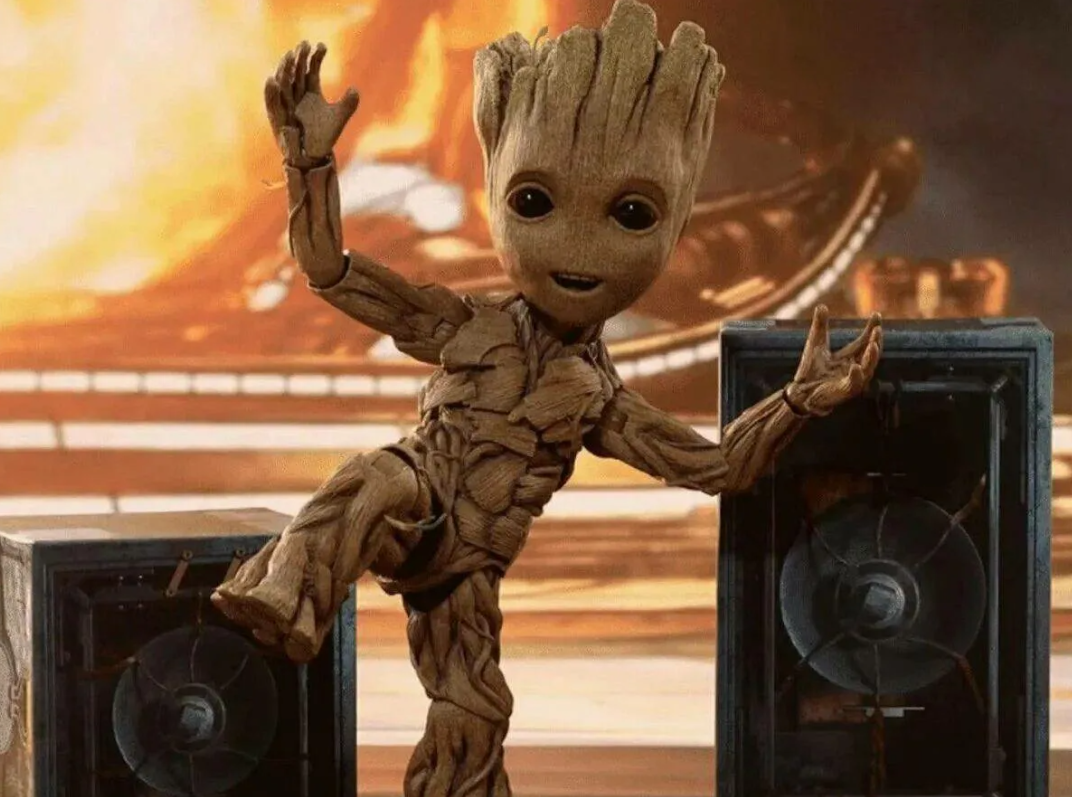